In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams.update({'font.size': 14})

In [3]:
time = pl.read_csv("data/export-BlockTime.csv", separator=",", try_parse_dates=True)
time = time.with_columns(pl.col("Date(UTC)").str.strptime(pl.Date, format="%m/%d/%Y").alias("dt_date"))
time

Date(UTC),UnixTimeStamp,Value,dt_date
str,i64,f64,date
"""7/30/2015""",1438214400,4.46,2015-07-30
"""7/31/2015""",1438300800,12.58,2015-07-31
"""8/1/2015""",1438387200,16.34,2015-08-01
"""8/2/2015""",1438473600,16.12,2015-08-02
"""8/3/2015""",1438560000,16.37,2015-08-03
…,…,…,…
"""5/9/2026""",1778284800,12.04,2026-05-09
"""5/10/2026""",1778371200,12.03,2026-05-10
"""5/11/2026""",1778457600,12.05,2026-05-11


In [4]:
start_date = pl.datetime(2025, 1, 1)
end_date = pl.datetime(2025, 12, 31)
avg_time = round(time.filter((pl.col("dt_date") >= start_date) & (pl.col("dt_date") <= end_date))['Value'].median())
print(avg_time)

12


In [3]:
gas = pl.read_csv("data/export-AvgGasPrice.csv", separator=",", try_parse_dates=True)
gas = gas.with_columns(pl.col("Date(UTC)").str.strptime(pl.Date, format="%m/%d/%Y").alias("dt_date"))
gas

Date(UTC),UnixTimeStamp,Value (Wei),dt_date
str,i64,i64,date
"""7/30/2015""",1438214400,0,2015-07-30
"""7/31/2015""",1438300800,0,2015-07-31
"""8/1/2015""",1438387200,0,2015-08-01
"""8/2/2015""",1438473600,0,2015-08-02
"""8/3/2015""",1438560000,0,2015-08-03
…,…,…,…
"""4/16/2026""",1776297600,770524214,2026-04-16
"""4/17/2026""",1776384000,1894369818,2026-04-17
"""4/18/2026""",1776470400,1826432633,2026-04-18


In [4]:
ether = pl.read_csv("data/export-EtherPrice.csv", separator=",", try_parse_dates=True)
ether = ether.with_columns(pl.col("Date(UTC)").str.strptime(pl.Date, format="%m/%d/%Y").alias("dt_date"))
ether

Date(UTC),UnixTimeStamp,Value,dt_date
str,i64,f64,date
"""7/30/2015""",1438214400,0.0,2015-07-30
"""7/31/2015""",1438300800,0.0,2015-07-31
"""8/1/2015""",1438387200,0.0,2015-08-01
"""8/2/2015""",1438473600,0.0,2015-08-02
"""8/3/2015""",1438560000,0.0,2015-08-03
…,…,…,…
"""4/17/2026""",1776384000,2419.96,2026-04-17
"""4/18/2026""",1776470400,2351.39,2026-04-18
"""4/19/2026""",1776556800,2263.9,2026-04-19


In [5]:
start_date = pl.datetime(2025, 1, 1)
end_date = pl.datetime(2025, 12, 31)
avg_gas_price = round(gas.filter((pl.col("dt_date") >= start_date) & (pl.col("dt_date") <= end_date))['Value (Wei)'].mean())
avg_eth_price = round(ether.filter((pl.col("dt_date") >= start_date) & (pl.col("dt_date") <= end_date))['Value'].mean())

def gas2usd(x):
  return x * avg_gas_price * 1e-18 * avg_eth_price

def usd2gas(x):
  return x / (avg_gas_price * 1e-18 * avg_eth_price)


In [7]:
gas2usd(900_000)

9.6696319714416

In [76]:
df = pl.read_csv("data/OracleVerifierDeployment.tsv", separator="\t")
df

f,n_min,gas_cost
i64,i64,i64
1,4,1855651
2,7,1924651
3,10,1993735
4,13,2062711
5,16,2131783
6,19,2200843
7,22,2269867
8,25,2338891
9,28,2407927


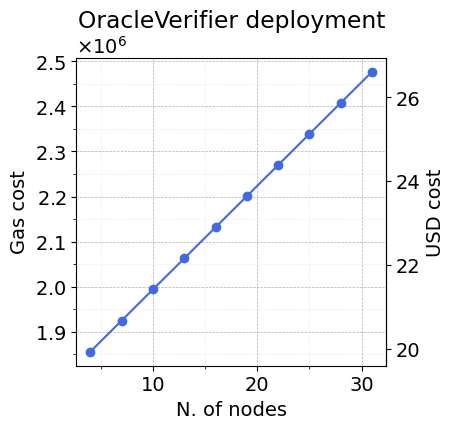

In [77]:
plt.figure(figsize=(4, 4))
plt.title('OracleVerifier deployment')
plt.plot(df['n_min'], df['gas_cost'], color="royalblue", marker = 'o')
plt.xlabel('N. of nodes')
plt.ylabel('Gas cost')

formatter = matplotlib.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((6, 6))

ax = plt.gca()
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_major_formatter(formatter)

secax = ax.secondary_yaxis('right', functions=(gas2usd, usd2gas))
secax.set_ylabel('USD cost')

plt.savefig("figures/oracleverifier-deployment.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [78]:
df = pl.read_csv("data/RoyaltyManagerDeployment.tsv", separator="\t").filter(pl.col("n_holders") <= 1000)
df

n_holders,gas_cost
i64,i64
1,1191137
5,1282637
10,1397039
50,2312123
100,3456130
500,12611330
1000,24058633


Per questa sotto fare in modo che venga 10^6 su asse y come ordine di grandezza.

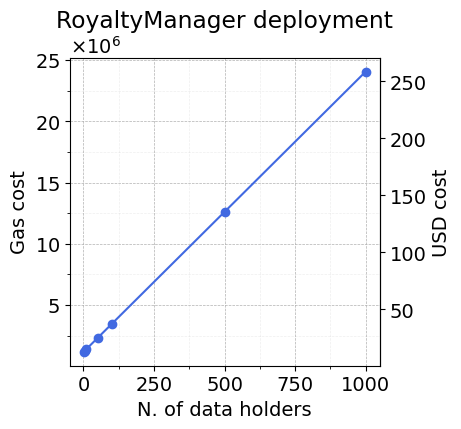

In [79]:
plt.figure(figsize=(4, 4))
plt.title('RoyaltyManager deployment')
plt.plot(df['n_holders'], df['gas_cost'], color="royalblue", marker = 'o')
plt.xlabel('N. of data holders')
plt.ylabel('Gas cost')

formatter = matplotlib.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((6, 6))

ax = plt.gca()
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_major_formatter(formatter)
#ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
#ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1e6))

secax = ax.secondary_yaxis('right', functions=(gas2usd, usd2gas))
secax.set_ylabel('USD cost')

plt.savefig("figures/royaltymanager-deployment.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Transmit gas costs

In [20]:
df = pd.read_csv("data/transmit.tsv", sep="\t")
df

,num_nodes,report_size,gas_used,transmit_a,transmit_v,dist_rew,rew_holders
0,4,10,316403,284765,271608,83270,39886
1,4,25,379241,345683,332434,118055,74671
2,4,50,480482,443724,430319,176114,132730
3,4,100,685694,642536,628811,292238,248854
4,4,250,1302094,1239736,1224994,641080,597696
...,...,...,...,...,...,...,...
65,31,50,745958,681324,667573,176114,132730
66,31,100,951238,880168,866087,292238,248854
67,31,250,1567721,1477463,1462333,641080,597696
68,31,500,2597809,2475491,2458418,1224044,1180660


In [21]:
gas_other = df['gas_used']-df['transmit_a']
gas_ta = df['transmit_a']-df['transmit_v']
gas_tv = df['transmit_v']-df['dist_rew']
gas_dr = df['dist_rew']-df['rew_holders']
gas_rh = df['rew_holders']
transmit_gas = pd.DataFrame({
    'num_nodes':df['num_nodes'],
    'report_size':df['report_size'],
    'gas_other':gas_other,
    'gas_ta':gas_ta,
    'gas_tv':gas_tv,
    'gas_dr':gas_dr,
    'gas_rh':gas_rh
})
transmit_gas

,num_nodes,report_size,gas_other,gas_ta,gas_tv,gas_dr,gas_rh
0,4,10,31638,13157,188338,43384,39886
1,4,25,33558,13249,214379,43384,74671
2,4,50,36758,13405,254205,43384,132730
3,4,100,43158,13725,336573,43384,248854
4,4,250,62358,14742,583914,43384,597696
...,...,...,...,...,...,...,...
65,31,50,64634,13751,491459,43384,132730
66,31,100,71070,14081,573849,43384,248854
67,31,250,90258,15130,821253,43384,597696
68,31,500,122318,17073,1234374,43384,1180660


In [23]:
tgf = transmit_gas[transmit_gas['report_size'] == 1000].sort_values('num_nodes')
tgf

,num_nodes,report_size,gas_other,gas_ta,gas_tv,gas_dr,gas_rh
6,4,1000,158370,21147,1825890,43384,2352448
13,7,1000,161466,21207,1847256,43384,2352448
20,10,1000,164562,21267,1869882,43384,2352448
27,13,1000,167634,21327,1893768,43384,2352448
34,16,1000,170754,21388,1918914,43384,2352448
41,19,1000,173850,21448,1945320,43384,2352448
48,22,1000,176958,21509,1972986,43384,2352448
55,25,1000,180066,21570,2001912,43384,2352448
62,28,1000,183174,21631,2032099,43384,2352448
69,31,1000,186270,21692,2063546,43384,2352448


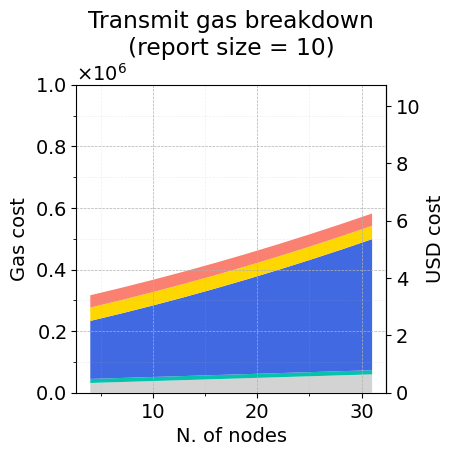

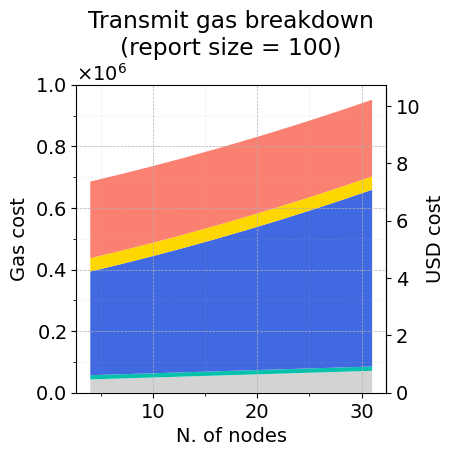

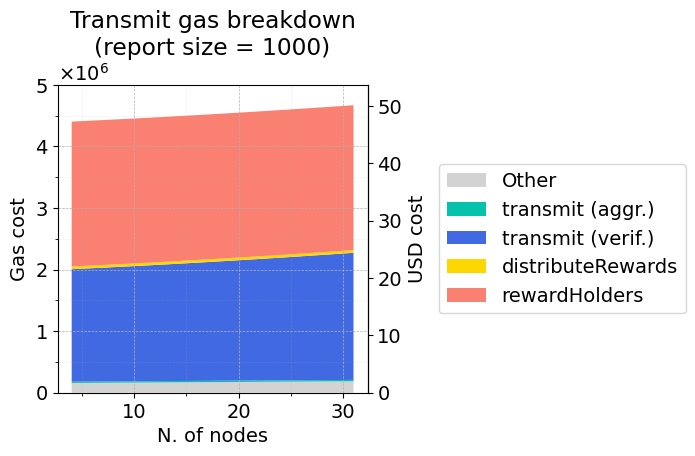

In [82]:
report_sizes = [10, 100, 1000]
formatter = matplotlib.ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((6, 6))
for report_size in report_sizes:
    tgf = transmit_gas[transmit_gas['report_size'] == report_size].sort_values('num_nodes')
    plt.figure(figsize=(4, 4))
    plt.title(f"Transmit gas breakdown\n(report size = {report_size})")
    plt.xlabel('N. of nodes')
    plt.ylabel('Gas cost')
    plt.stackplot(
        tgf['num_nodes'],
        tgf['gas_other'],
        tgf['gas_ta'],
        tgf['gas_tv'],
        tgf['gas_dr'],
        tgf['gas_rh'],
        labels=['Other', 'transmit (aggr.)', 'transmit (verif.)', 'distributeRewards', 'rewardHolders'],
        colors=['lightgray', '#06C2AC', 'royalblue', 'gold', 'salmon']
        #alpha=0.8
    )
    ax = plt.gca()
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    ax.yaxis.set_major_formatter(formatter)
    secax = ax.secondary_yaxis('right', functions=(gas2usd, usd2gas))
    secax.set_ylabel('USD cost')
    if report_size in [10, 100]:
        plt.yticks([i * 1e5 for i in np.arange(0, 10+2, 2)])
    if report_size in [1000]:
        plt.yticks([i * 1e6 for i in np.arange(0, 5+1)])
        plt.legend(loc='center left', bbox_to_anchor=(1.2, 0.5))
    plt.savefig(f"figures/transmit-breakdown-{report_size}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

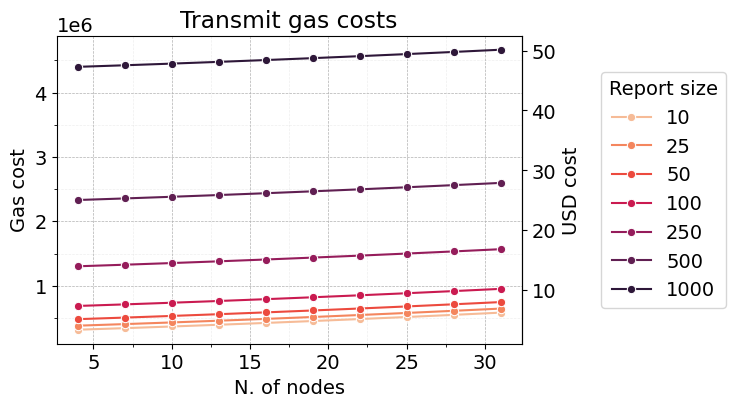

In [19]:
fig = plt.figure(figsize=(6, 4))
ax1 = fig.add_subplot()
ax1.set_title('Transmit gas costs')
ax1.set_xlabel('N. of nodes')
ax1.set_ylabel('Gas cost')
sns.lineplot(data=df, x="num_nodes", y="gas_used", hue=df["report_size"].astype(str), palette="rocket_r", marker="o", ax=ax1)
ax1.legend(title="Report size", loc='center left', bbox_to_anchor=(1.15, 0.5))
#
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax1.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
secax = ax1.secondary_yaxis('right', functions=(gas2usd, usd2gas))
secax.set_ylabel('USD cost')
plt.savefig("figures/transmit.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Model execution time

In [83]:
df_a = pd.read_csv("data/attribution_runs.tsv", sep="\t")
df_g = pd.read_csv("data/generation_runs.tsv", sep="\t")

runs = [f"run_{i+1}" for i in range(0, 15)]

df_a["mean"] = df_a[runs].mean(axis=1)
df_a["std"] = df_a[runs].std(axis=1)

df_g["mean"] = df_g[runs].mean(axis=1)
df_g["std"] = df_g[runs].std(axis=1)

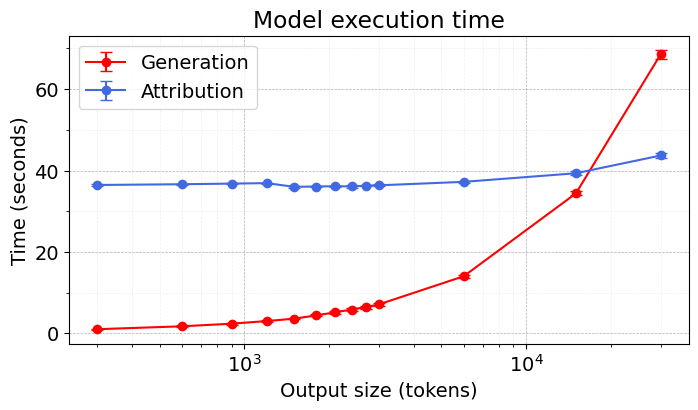

In [72]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot()
ax1.set_title('Model execution time')
ax1.set_xlabel('Output size (tokens)')
ax1.set_ylabel('Time (seconds)')
ax1.errorbar(df_g["size"], df_g["mean"], yerr=df_g["std"], color="red", fmt="o-", capsize=4, label="Generation")
ax1.errorbar(df_a["size"], df_a["mean"], yerr=df_a["std"], color="royalblue", fmt="o-", capsize=4, label="Attribution")
ax1.set_xscale('log')
ax1.legend()
plt.grid(which='major', linestyle='--', linewidth=0.5)
plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
#ax1.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
plt.savefig("figures/model-execution-time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [84]:
df_a

,size,run_1,run_2,run_3,run_4,run_5,run_6,run_7,run_8,run_9,run_10,run_11,run_12,run_13,run_14,run_15,mean,std
0,300,36.097,35.503,35.997,36.703,36.438,36.641,36.544,36.761,36.580,36.791,36.479,36.620,36.571,36.553,36.532,36.454000,0.340952
1,600,36.562,36.717,36.581,36.789,36.525,36.637,36.538,36.729,36.600,36.502,36.519,36.637,36.777,36.623,36.808,36.636267,0.104068
2,900,36.750,36.739,36.649,36.735,36.990,36.850,36.824,36.676,37.024,36.742,36.744,36.825,36.770,36.741,36.852,36.794067,0.104080
3,1200,36.990,36.857,37.080,36.804,37.124,36.682,37.022,36.892,36.943,36.885,36.921,36.972,36.758,36.975,36.740,36.909667,0.125897
4,1500,35.671,35.559,35.815,35.931,35.974,35.941,35.958,36.140,36.973,36.275,35.963,35.894,36.016,35.971,35.959,36.002667,0.316776
5,1800,36.055,36.028,36.201,35.973,36.085,36.024,36.001,36.298,35.965,36.196,35.914,36.026,36.150,36.055,36.126,36.073133,0.103659
6,2100,36.112,36.112,36.327,36.063,36.225,36.118,36.035,36.294,36.138,36.228,36.082,36.076,36.015,36.084,36.430,36.155933,0.119277
7,2400,35.046,35.788,36.169,36.009,36.275,36.313,36.150,36.196,36.155,36.405,36.190,36.231,36.091,36.176,36.161,36.090333,0.320546
8,2700,36.198,36.629,36.186,36.216,36.350,36.219,36.552,36.193,36.249,36.255,36.124,36.373,36.291,36.196,36.140,36.278067,0.144648
9,3000,35.903,36.172,36.610,36.220,36.751,36.412,36.224,36.287,36.289,36.659,36.329,36.395,36.403,36.348,36.535,36.369133,0.212754


## Latency evaluation

In [20]:
nodes = [4, 7, 10, 13, 16]
sizes = [300, 3000, 30000]
df = dict()
for n in nodes:
    f = (n - 1) // 3
    for s in sizes:
        df[(str(n), "0", str(s))] = pd.read_csv(f"results/benchmark_results_n={n}_f=0_q={s}.csv")
        df[(str(n), f"{f}a", str(s))] = pd.read_csv(f"results/benchmark_results_n={n}_f={f}a_q={s}.csv")
        df[(str(n), f"{f}t", str(s))] = pd.read_csv(f"results/benchmark_results_n={n}_f={f}t_q={s}.csv")

avgs = dict()
stds = dict()
for n in nodes:
    f = (n - 1) // 3
    for s in sizes:
        avgs[(str(n), "0", str(s))] = float(df[(str(n), "0", str(s))]['Total_Latency(ms)'].mean())
        stds[(str(n), "0", str(s))] = float(df[(str(n), "0", str(s))]['Total_Latency(ms)'].std())
        avgs[(str(n), f"{f}a", str(s))] = float(df[(str(n), f"{f}a", str(s))]['Total_Latency(ms)'].mean())
        stds[(str(n), f"{f}a", str(s))] = float(df[(str(n), f"{f}a", str(s))]['Total_Latency(ms)'].std())
        avgs[(str(n), f"{f}t", str(s))] = float(df[(str(n), f"{f}t", str(s))]['Total_Latency(ms)'].mean())
        stds[(str(n), f"{f}t", str(s))] = float(df[(str(n), f"{f}t", str(s))]['Total_Latency(ms)'].std())

In [21]:
nodes = [4, 7, 10, 13, 16]
sizes = [300, 3000, 30000]
latency = dict()
for s in sizes:
    latency[str(s)] = pd.DataFrame({
        'nodes': nodes, 
        'mean_n': [avgs[(str(n), "0", str(s))] for n in nodes],
        'std_n': [stds[(str(n), "0", str(s))] for n in nodes],
        'mean_ft': [avgs[(str(n), f"{(n-1)//3}t", str(s))] for n in nodes],
        'std_ft': [stds[(str(n), f"{(n-1)//3}t", str(s))] for n in nodes],
        'mean_fa': [avgs[(str(n), f"{(n-1)//3}a", str(s))] for n in nodes],
        'std_fa': [stds[(str(n), f"{(n-1)//3}a", str(s))] for n in nodes]
    })

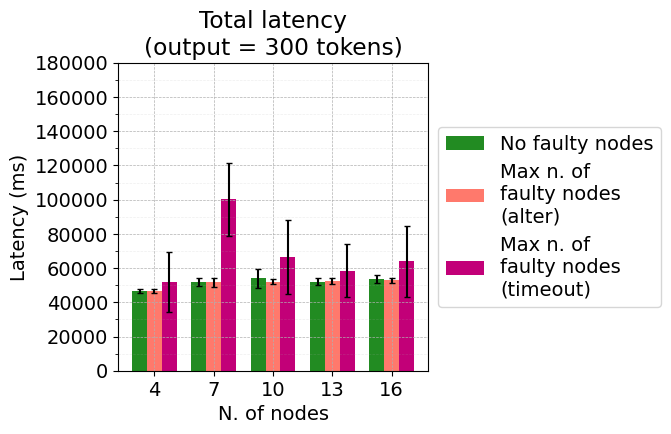

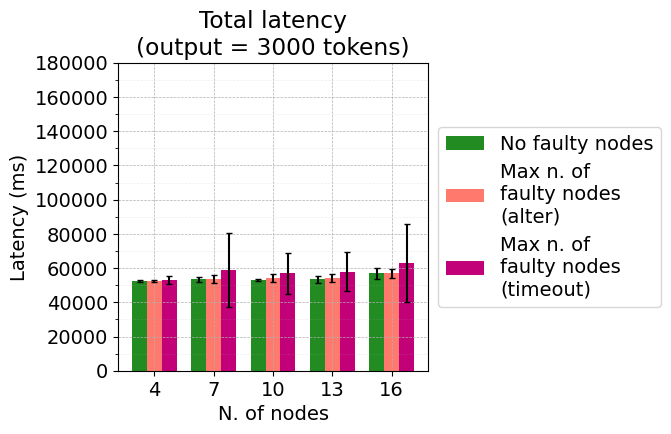

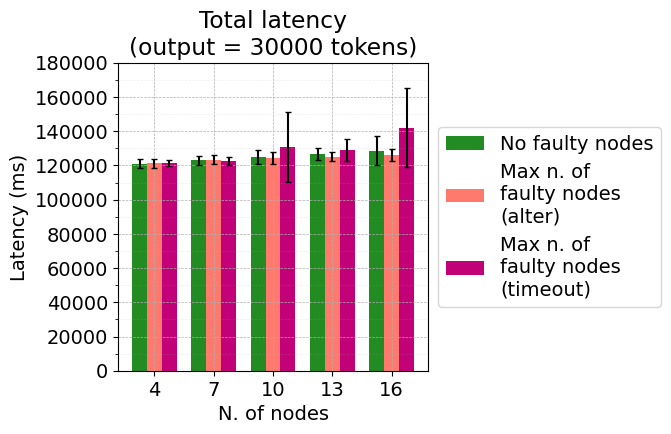

In [25]:
sizes = [300, 3000, 30000]
for s in sizes:
    # Data
    nodes = latency[str(s)]['nodes']
    # Positions
    x = np.arange(len(nodes))
    width = 0.25
    # Plot
    plt.figure(figsize=(4, 4))
    plt.title('Total latency\n(output = ' + str(s) + ' tokens)')
    plt.xlabel('N. of nodes')
    plt.ylabel('Latency (ms)')
    plt.bar(x - width, latency[str(s)]['mean_n'], width, yerr=latency[str(s)]['std_n'], capsize=2, color="forestgreen", label='No faulty nodes')
    plt.bar(x, latency[str(s)]['mean_fa'], width, yerr=latency[str(s)]['std_fa'], capsize=2, color="#FF796C", label='Max n. of\nfaulty nodes\n(alter)')
    plt.bar(x + width, latency[str(s)]['mean_ft'], width, yerr=latency[str(s)]['std_ft'], capsize=2, color="#C20078", label='Max n. of\nfaulty nodes\n(timeout)')
    plt.xticks(x, nodes)
    plt.yticks([i*10**4 for i in range(0, 20, 2)])
    plt.grid(which='major', linestyle='--', linewidth=0.5)
    plt.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    plt.gca().yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.savefig(f"figures/latency-total-{s}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

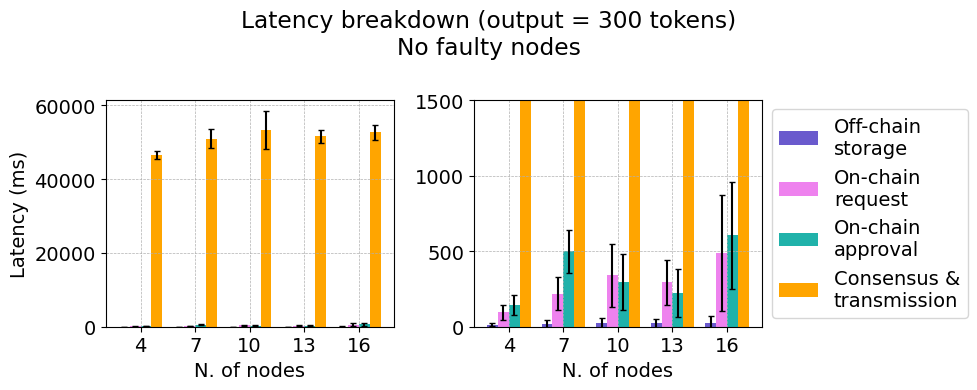

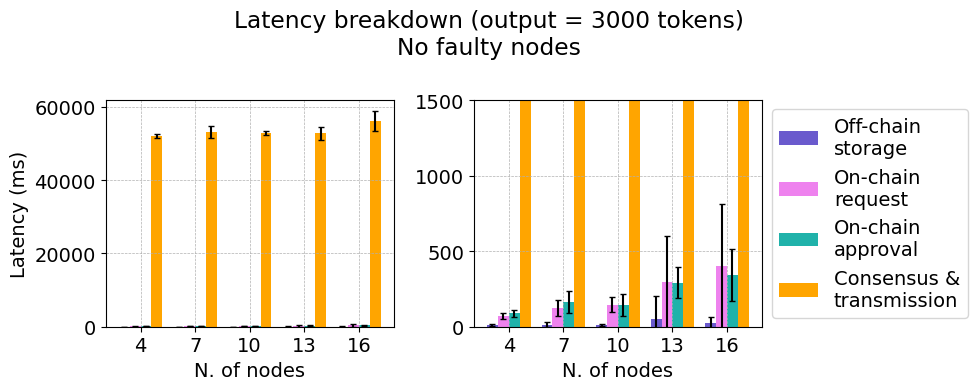

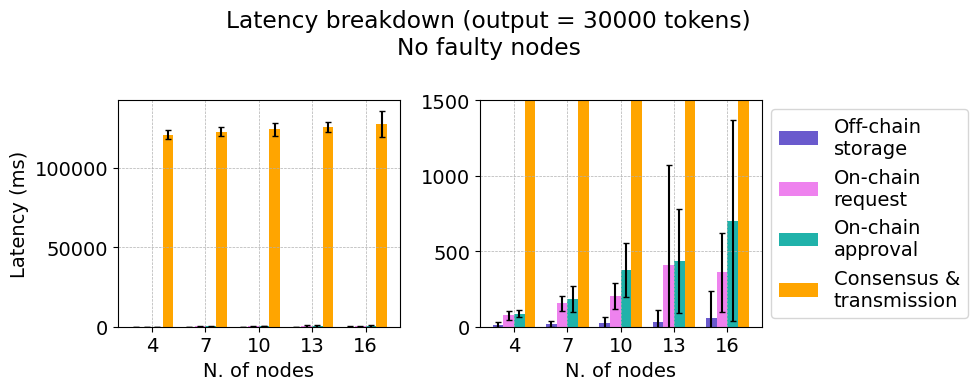

In [26]:
# Phases
columns = ["OffChain_Storage(ms)", "OnChain_RequestTx(ms)", "OnChain_ApprovalTx(ms)", "OCR_Consensus_And_FulfillmentTx(ms)"]
labels = ["Off-chain\nstorage", "On-chain\nrequest", "On-chain\napproval", "Consensus &\ntransmission"]
colors = ["slateblue", "violet", "lightseagreen", "orange"]
sizes = [300, 3000, 30000]

for s in sizes:
    means_4 = df["4", "0", str(s)][columns].mean().to_list()
    stds_4 = df["4", "0", str(s)][columns].std().to_list()
    means_7 = df["7", "0", str(s)][columns].mean().to_list()
    stds_7  = df["7", "0", str(s)][columns].std().to_list()
    means_10 = df["10", "0", str(s)][columns].mean().to_list()
    stds_10  = df["10", "0", str(s)][columns].std().to_list()
    means_13 = df["13", "0", str(s)][columns].mean().to_list()
    stds_13  = df["13", "0", str(s)][columns].std().to_list()
    means_16 = df["16", "0", str(s)][columns].mean().to_list()
    stds_16  = df["16", "0", str(s)][columns].std().to_list()

    group_x = np.arange(5)
    # Bar width and offsets (4 bars per group)
    width = 0.2
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Latency breakdown (output = {s} tokens)\nNo faulty nodes")
    # Full version
    for i in range(4):
        ax1.bar(group_x + offsets[i],
                [means_4[i], means_7[i], means_10[i], means_13[i], means_16[i]],
                width,
                yerr=[stds_4[i], stds_7[i], stds_10[i], stds_13[i], stds_16[i]],
                capsize=2,
                label=labels[i], color=colors[i])
    ax1.set_ylim(bottom=0)
    ax1.set_xticks(group_x)
    ax1.set_xticklabels(['4', '7', '10', '13', '16'])
    ax1.set_xlabel("N. of nodes")
    ax1.set_ylabel("Latency (ms)")
    ax1.grid(which='major', linestyle='--', linewidth=0.5)
    ax1.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    # Zoomed-in version
    for i in range(4):
        ax2.bar(group_x + offsets[i],
                [means_4[i], means_7[i], means_10[i], means_13[i], means_16[i]],
                width,
                yerr=[stds_4[i], stds_7[i], stds_10[i], stds_13[i], stds_16[i]],
                capsize=2,
                label=labels[i], color=colors[i])
    
    ax2.set_xticks(group_x)
    ax2.set_xticklabels(['4', '7', '10', '13', '16'])
    ax2.set_ylim(bottom=0, top=1500)
    ax2.set_xlabel("N. of nodes")
    ax2.grid(which='major', linestyle='--', linewidth=0.5)
    ax2.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    ax2.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.savefig(f"figures/latency-breakdown-nf-{s}.pdf", format='pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

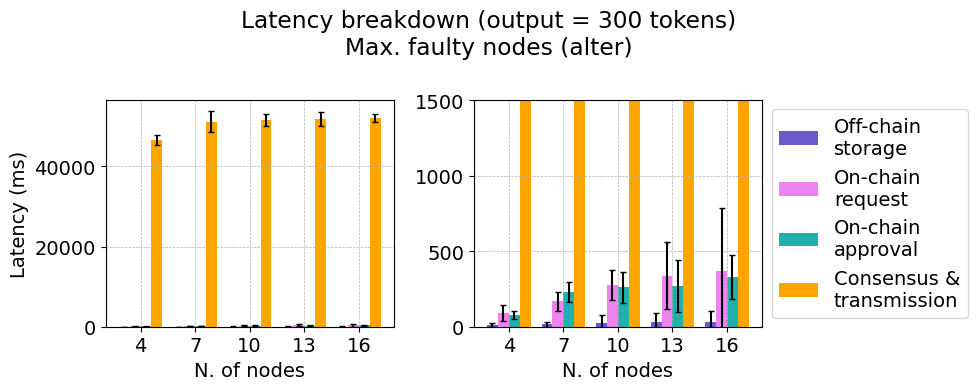

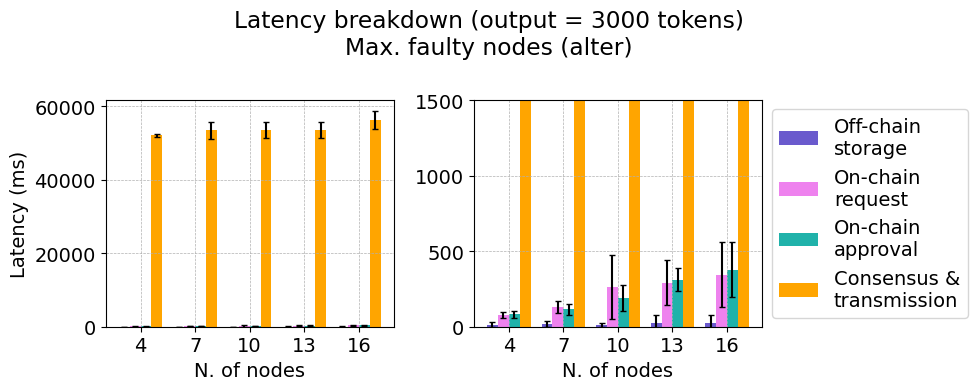

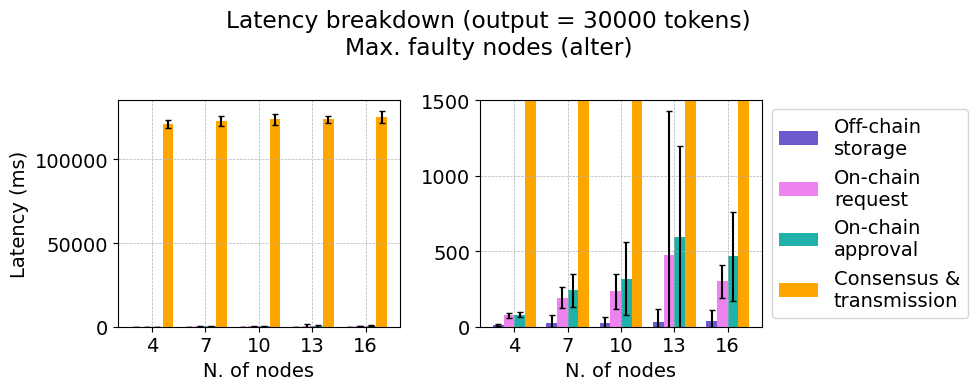

In [ ]:
# Phases
columns = ["OffChain_Storage(ms)", "OnChain_RequestTx(ms)", "OnChain_ApprovalTx(ms)", "OCR_Consensus_And_FulfillmentTx(ms)"]
labels = ["Off-chain\nstorage", "On-chain\nrequest", "On-chain\napproval", "Consensus &\ntransmission"]
colors = ["slateblue", "violet", "lightseagreen", "orange"]
sizes = [300, 3000, 30000]

for s in sizes:
    means_4 = df["4", "1a", str(s)][columns].mean().to_list()
    stds_4 = df["4", "1a", str(s)][columns].std().to_list()
    means_7 = df["7", "2a", str(s)][columns].mean().to_list()
    stds_7  = df["7", "2a", str(s)][columns].std().to_list()
    means_10 = df["10", "3a", str(s)][columns].mean().to_list()
    stds_10  = df["10", "3a", str(s)][columns].std().to_list()
    means_13 = df["13", "4a", str(s)][columns].mean().to_list()
    stds_13  = df["13", "4a", str(s)][columns].std().to_list()
    means_16 = df["16", "5a", str(s)][columns].mean().to_list()
    stds_16  = df["16", "5a", str(s)][columns].std().to_list()

    group_x = np.arange(5)
    # Bar width and offsets (4 bars per group)
    width = 0.2
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Latency breakdown (output = {s} tokens)\nMax. faulty nodes (alter)")
    # Full version
    for i in range(4):
        ax1.bar(group_x + offsets[i],
                [means_4[i], means_7[i], means_10[i], means_13[i], means_16[i]],
                width,
                yerr=[stds_4[i], stds_7[i], stds_10[i], stds_13[i], stds_16[i]],
                capsize=2,
                label=labels[i], color=colors[i])
    ax1.set_ylim(bottom=0)
    ax1.set_xticks(group_x)
    ax1.set_xticklabels(['4', '7', '10', '13', '16'])
    ax1.set_xlabel("N. of nodes")
    ax1.set_ylabel("Latency (ms)")
    ax1.grid(which='major', linestyle='--', linewidth=0.5)
    ax1.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    # Zoomed-in version
    for i in range(4):
        ax2.bar(group_x + offsets[i],
                [means_4[i], means_7[i], means_10[i], means_13[i], means_16[i]],
                width,
                yerr=[stds_4[i], stds_7[i], stds_10[i], stds_13[i], stds_16[i]],
                capsize=2,
                label=labels[i], color=colors[i])
    
    ax2.set_xticks(group_x)
    ax2.set_xticklabels(['4', '7', '10', '13', '16'])
    ax2.set_ylim(bottom=0, top=1500)
    ax2.set_xlabel("N. of nodes")
    ax2.grid(which='major', linestyle='--', linewidth=0.5)
    ax2.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    ax2.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.savefig(f"figures/latency-breakdown-fa-{s}.pdf", format='pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

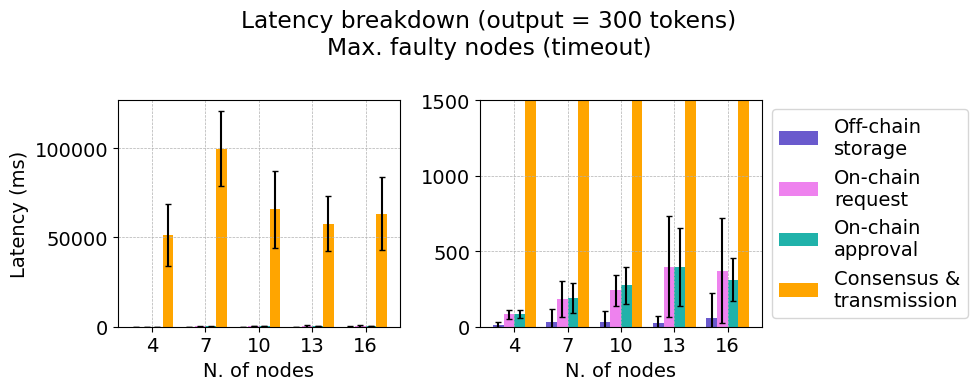

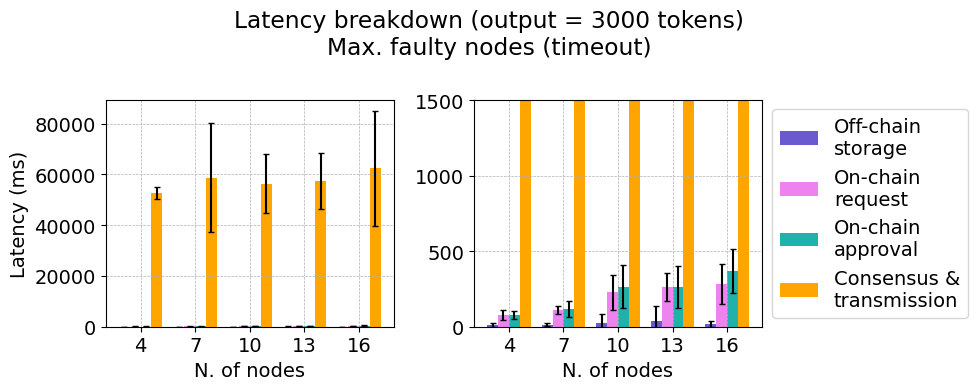

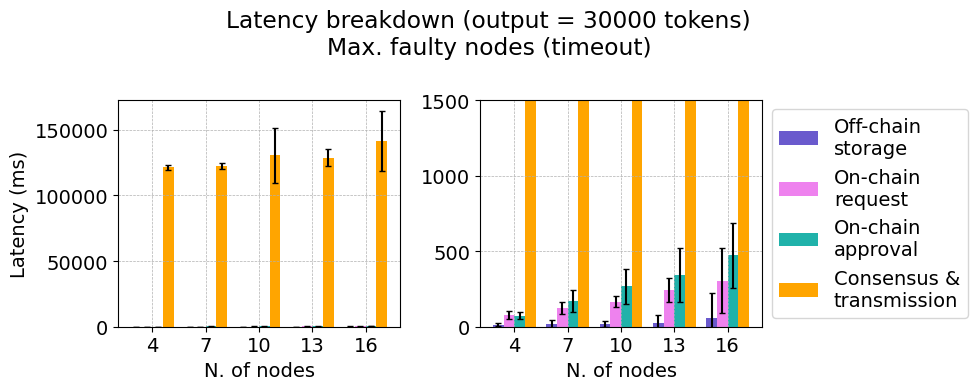

In [28]:
# Phases
columns = ["OffChain_Storage(ms)", "OnChain_RequestTx(ms)", "OnChain_ApprovalTx(ms)", "OCR_Consensus_And_FulfillmentTx(ms)"]
labels = ["Off-chain\nstorage", "On-chain\nrequest", "On-chain\napproval", "Consensus &\ntransmission"]
colors = ["slateblue", "violet", "lightseagreen", "orange"]
sizes = [300, 3000, 30000]

for s in sizes:
    means_4 = df["4", "1t", str(s)][columns].mean().to_list()
    stds_4 = df["4", "1t", str(s)][columns].std().to_list()
    means_7 = df["7", "2t", str(s)][columns].mean().to_list()
    stds_7  = df["7", "2t", str(s)][columns].std().to_list()
    means_10 = df["10", "3t", str(s)][columns].mean().to_list()
    stds_10  = df["10", "3t", str(s)][columns].std().to_list()
    means_13 = df["13", "4t", str(s)][columns].mean().to_list()
    stds_13  = df["13", "4t", str(s)][columns].std().to_list()
    means_16 = df["16", "5t", str(s)][columns].mean().to_list()
    stds_16  = df["16", "5t", str(s)][columns].std().to_list()

    group_x = np.arange(5)
    # Bar width and offsets (4 bars per group)
    width = 0.2
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * width

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Latency breakdown (output = {s} tokens)\nMax. faulty nodes (timeout)")
    # Full version
    for i in range(4):
        ax1.bar(group_x + offsets[i],
                [means_4[i], means_7[i], means_10[i], means_13[i], means_16[i]],
                width,
                yerr=[stds_4[i], stds_7[i], stds_10[i], stds_13[i], stds_16[i]],
                capsize=2,
                label=labels[i], color=colors[i])
    ax1.set_ylim(bottom=0)
    ax1.set_xticks(group_x)
    ax1.set_xticklabels(['4', '7', '10', '13', '16'])
    ax1.set_xlabel("N. of nodes")
    ax1.set_ylabel("Latency (ms)")
    ax1.grid(which='major', linestyle='--', linewidth=0.5)
    ax1.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    # Zoomed-in version
    for i in range(4):
        ax2.bar(group_x + offsets[i],
                [means_4[i], means_7[i], means_10[i], means_13[i], means_16[i]],
                width,
                yerr=[stds_4[i], stds_7[i], stds_10[i], stds_13[i], stds_16[i]],
                capsize=2,
                label=labels[i], color=colors[i])
    
    ax2.set_xticks(group_x)
    ax2.set_xticklabels(['4', '7', '10', '13', '16'])
    ax2.set_ylim(bottom=0, top=1500)
    ax2.set_xlabel("N. of nodes")
    ax2.grid(which='major', linestyle='--', linewidth=0.5)
    ax2.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
    ax2.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    plt.savefig(f"figures/latency-breakdown-ft-{s}.pdf", format='pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()